# Standard dynamic analysis with HERMESS

*PowerUp 2026, hands-on: the same study in code (about 10 minutes)*

HERMESS simulates power systems written as nonlinear differential-algebraic
equations (DAEs). The desktop GUI just ran a study on a small system: pick it,
set the options, run, read the modes. This notebook reproduces that session in
one call, then covers what the code adds, one function at a time:

1. the shipped systems and the two text files that define one,
2. the GUI session in one call,
3. a local copy of a system, ready to edit,
4. a run with our own settings,
5. the one-line diagram,
6. any quantity by name, plotted,
7. metrics,
8. a different disturbance, and two runs compared,
9. quasi-static versus dynamic network in one flag,
10. eigenvalues and participation factors in one call,
11. a slider on a droop gain and an inertia.

The package core is `hermess` (`hermess.simulate`, the systems, the registry).
Its notebook layer, `hermess.analysis`, is imported as `ha` below, so every
`ha.` call in this notebook is a plotting, table or file helper from that
layer. Each function shows its full argument list with `ha.plot?` (or
Shift+Tab inside the brackets), the docs page "Analysis and plotting" carries
the same material, and the table at the end maps every function used here to
its section.

## 0. Setup

On Colab, the first cell installs `hermess` from PyPI (about a minute); that is
the entire setup. Locally, run inside the workshop environment and it does
nothing.

In [1]:
import importlib.metadata, importlib.util, os, subprocess, sys

if importlib.util.find_spec("hermess") is None:                      # Colab
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "hermess>=1.7.1"])
    # Colab preimports numpy; if pip just upgraded it, the kernel holds a stale
    # mix of old and new files. A one-time restart fixes it; the install sticks.
    stale = [m for m in ("numpy", "pandas", "matplotlib") if m in sys.modules
             and importlib.metadata.version(m) != sys.modules[m].__version__]
    if stale:
        print("pip upgraded", ", ".join(stale), "under the running kernel;")
        print("restarting the runtime now. When it reconnects (a few seconds),")
        print("run the cells again from the top; the install is already done.")
        os.kill(os.getpid(), 9)

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hermess
import hermess.analysis as ha

print("hermess", hermess.__version__)
assert tuple(int(x) for x in hermess.__version__.split(".")[:3]) >= (1, 7, 1), \
    "this notebook needs hermess 1.7.1 or newer: pip install -U hermess"

hermess 1.7.1


`hermess.analysis` draws in whatever matplotlib style is active and imposes no
solver settings, so this cell holds the two notebook-side pieces: the ETH plot
style, and `WS`, the run settings every simulation in this notebook shares.
`run` is `hermess.simulate` with those settings pre-filled. Delete this cell and
everything still works, in matplotlib's default style and hermess's default
configuration.

In [3]:
ETH = {"blue": "#215CAF", "petrol": "#007894", "green": "#627313", "bronze": "#8E6713",
       "red": "#B7352D", "purple": "#A7117A", "grey": "#6F6F6F"}
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=[ETH[k] for k in
        ("blue", "petrol", "red", "green", "bronze", "purple", "grey")]),
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm", "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "legend.frameon": False,
})

WS = dict(line_dyn=True, ts=0.001, incl_lim=False, quiet=True,       # the workshop's run settings
          int_scheme_sim_options={"reltol": 1e-8, "abstol": 1e-10,
                                  "max_num_steps": 100000, "jit": False})

def run(system, **overrides):
    """hermess.simulate() with the workshop settings pre-filled; any Config field overrides."""
    return hermess.simulate(system, **{**WS, **overrides})

## 1. Shipped systems and where they live

The package ships 39 ready-made systems, in one folder each inside the package's
system directory. Every system folder holds two files:

* `sim_param.txt`: devices (one row each, `Class, idx = ..., bus = ..., params`),
  network branches (`Line, ...`), and the bus data used by the initial power flow
  (`BusInit, ...`).
* `sim_dist.txt`: the disturbances, one row each, with a time and a type.

For this tutorial, we use a three-bus system: a synchronous machine (slack) at
bus 1, a constant impedance load at bus 2, and a droop grid-forming converter at
bus 3.

```
     bus 1 ─────────── bus 2 ─────────── bus 3
       │                 │                 │
      SG1              load              GFMI2
  synchronous        (impedance)      grid-forming
    machine                             converter
       └───────────────────────────────────┘
```

In [4]:
print(hermess.SYSTEMS_DIR)                 # where the shipped systems live
ha.list_systems()

/Users/mdesai/Projects/hermess-main/hermess/systems


['3bus',
 '3bus_avrac1a',
 '3bus_avrst1a',
 '3bus_dynlines_psid',
 '3bus_genrou',
 '3bus_genrou_psse',
 '3bus_gensal',
 '3bus_gfm_psid',
 '3bus_ieeedc1a',
 '3bus_loadstep',
 '3bus_marconato_pscad',
 '3bus_psskundur',
 '3bus_sauerpai_psid',
 '3bus_sexst',
 '3bus_shaft5mass_psid',
 '3bus_tgov1',
 'ieee39',
 'ieee39_conv',
 'ieee39_conv_old',
 'ieee39_ideal',
 'kundur',
 'kundur_conv',
 'omib_gfl_pscad',
 'omib_gfm_pscad',
 'omib_vsm_pscad',
 'sea14gen/case1',
 'sea14gen/case1_conv',
 'sea14gen/case1_nopss',
 'sea14gen/case2',
 'sea14gen/case2_nopss',
 'sea14gen/case3',
 'sea14gen/case3_nopss',
 'sea14gen/case4',
 'sea14gen/case4_nopss',
 'sea14gen/case5',
 'sea14gen/case5_nopss',
 'sea14gen/case6',
 'sea14gen/case6_nopss',
 'sea14gen/smib']

## 2. The GUI session, in one call

The GUI (`hermess-gui`, installed with `pip install "hermess[gui]"`) is a front end
over the same package: its systems tree is `ha.list_systems()`, its options
dialog is generated from the `Config` object, Run calls `hermess.simulate()` in a
worker process, and its builder writes ordinary system folders that this notebook
runs unchanged. So the session you watched can be reproduced here. One call runs
the system, prints the initial power flow (the Power flow tab) and the modal
report (the Small signal tab); the Time domain tab is the returned object,
plotted, which is what the rest of this notebook does.

In [5]:
dae0 = hermess.simulate("3bus_loadstep", T_end=5.0, print_power_flow=True,
                        small_signal_analysis=True, small_signal_figures=False)


Power flow for initialization successfully solved
Power Flow: Bus Results
      Bus    V Magnitude (pu)    V Phase (deg)    P Gen (MW)    Q Gen (MVAr)    P Shunt (MW)    Q Shunt (MVAr)    P Shunt Trafo (MW)    Q Shunt Trafo (MVAr)
--  -----  ------------------  ---------------  ------------  --------------  --------------  ----------------  --------------------  ----------------------
 0      1            1            -1.22108e-25       50.8463       -1.05752         0.1               -5.25                 0.1                     -5.25
 1      2            0.992809     -2.53008         -100           -10               0.197134          -3.94268              0.197134                -3.94268
 2      3            1             0.0795449         50             0.177044        0.2               -6.25                 0.2                     -6.25
-------------------------------------------------------------------------------------------------------
Power Flow: Branch Results
      From Bus 


Small-signal modal analysis: 22 modes (0 unstable) over 38 states, sorted by damping ratio (most critical first).
| #   | Eigenvalue (σ±jω)     | f [Hz]   | ζ [%]   | Flag   | Dominant states (top 4, participation %)                                              |
|-----|-----------------------|----------|---------|--------|---------------------------------------------------------------------------------------|
| 1   | +0.000                | —        | -100.0  | zero   | GFM@3:delta_c (62%), SM_SP@1:delta (38%), BUS_2:vim (0%), LINE_3-1:i_iji (0%)         |
| 2   | -48.924 ± 12675.592j  | 2017.383 | +0.4    | low ζ  | BUS_3:vim (19%), BUS_3:vre (19%), LINE_1-2:i_iji (16%), LINE_1-2:i_ijr (16%)          |
| 3   | -53.029 ± 12047.010j  | 1917.341 | +0.4    | low ζ  | BUS_3:vre (19%), BUS_3:vim (19%), LINE_1-2:i_ijr (16%), LINE_1-2:i_iji (16%)          |
| 4   | -352.875 ± 4936.428j  | 785.657  | +7.1    |        | GFM@3:Vfd_ext (20%), GFM@3:Vfq_ext (20%), GFM@3:ifd_ext (16%), GFM@3:ifq_

Simulation:   0%|          | 0.0/100% [00:00<?]

Simulation:  20%|██        | 20.0/100% [00:00<00:02]

Simulation: 100%|██████████| 100.0/100% [00:01<00:00]

Simulation: 100%|██████████| 100.0/100% [00:01<00:00]

## 3. Setting up your workflow

The shipped systems are read-only. Copy the systems you would like to use into a
local directory and edit them there before simulating: `ha.copy_system` copies
the folder out of the installed package into a local `systems/` directory
(calling it again leaves your edits alone), and `ha.show_system` prints the two
files. The GUI's builder produces the same kind of folder.

In [6]:
SYS = "3bus_loadstep"
root = ha.copy_system(SYS)                 # -> ./systems/3bus_loadstep/, returns the root
print(f"the system lives in '{root}'")
ha.show_system(root, SYS)                  # both files

the system lives in '/Users/mdesai/Projects/PowerUp-hermess-workshop/notebooks/systems'
======================  3bus_loadstep/sim_param.txt  ======================
# ---------------------------------------------------------------------------
# 3-bus load-step demo system (simulation-only branch).
# A small three-bus network used to illustrate the active-power / frequency
# response of a droop grid-forming converter (GFM) to a small load step:
#       bus 1 ----(line)---- bus 2 ----(line)---- bus 3
#         |                    |                    |
#       SG1 (sync. gen.)     load (ZIP)         GFMI2 (grid-forming converter)
#         \__________________(line)__________________/
# The synchronous machine at bus 1 is the slack; the grid-forming converter at
# bus 3 provides the fast frequency response. A small constant-impedance load
# sits at bus 2. The matching load step is defined in sim_dist.txt.
# ---------------------------------------------------------------------------


# --

Things to notice:

* the class name in the first column selects the model (`SynchronousSubtransientSP`,
  `GridForming`, `StaticZIP`, `Line`, `BusInit`),
* parameters you leave out take the model's defaults,
* `BusInit` is only for the power flow that initializes the simulation at a steady state;
  the dynamic models are then initialized to match it (no "startup transient"),
* the disturbance is a +10 MW load step at bus 2 after 1 s.

## 4. Configure and run

Everything about *how* to simulate (time step, end time, integrator, reference frame,
which network model, what to print) is a `Config` object, the same pydantic model the
GUI renders as its options dialog, and `hermess.simulate` takes any of its fields
as a keyword. The fields used in this tutorial: `T_end`, `ts` (output step),
`line_dyn` (section 9), `incl_lim` (limiters), `int_scheme_sim` (`"idas"`,
`"cvodes"`, `"collocation"`, `"rk"`) with `int_scheme_sim_options` passed straight
to CasADi, `skip_disturance` (spelled like that upstream) for the pure steady
state, `small_signal_analysis`, `parametric` (notebook 02), `quiet`. `run` (from
the setup cell) only pre-fills the workshop settings `WS`.

In [7]:
dae = run(SYS, system_root=root, T_end=5.0)    # 5 s, 1 ms output step, dynamic lines
ha.summary(dae);

System '3bus_loadstep': 3 buses, 3 branches, 3 devices.
  devices     : SG1 (SynchronousSubtransientSP at bus 1), GFMI2 (GridForming at bus 3), Static_load_ZIP_1 (StaticZIP at bus 2)
  model size  : nx = 26 device states, ny = 6 algebraic (6 bus voltages + 0 private), nl = 6 line-current states
  network     : dynamic lines (EMT-like), 50 Hz, 100 MVA base, reference frame 'nom'
  time        : 0.0 to 5.0 s, output step 0.001 s
  disturbances: 1 s load at 2


`hermess.simulate` parsed the files, built the DAE symbolically with CasADi,
solved the initial power flow, initialized every device at steady state, and
integrated through the load step with an implicit DAE solver (IDAS). The returned
object holds the symbolic model *and* the trajectories. (`ha.power_flow_table(dae)`
gives the operating point it started from as a DataFrame, per bus or per branch.)

## 5. The one-line diagram

`ha.plot_system` draws the parsed system: a synchronous machine is a circle with
`∼`, a converter a split square (DC on one side, AC on the other), a load an arrow,
an SVC a diamond, and every device is labeled with its model type and rating. The
same call colors the buses by any signal at a chosen time (`color_by="bus*:v",
at=1.02`), writes the branch flows on the lines (`annotate_branches=True`), and
takes your own coordinates (`pos=`).

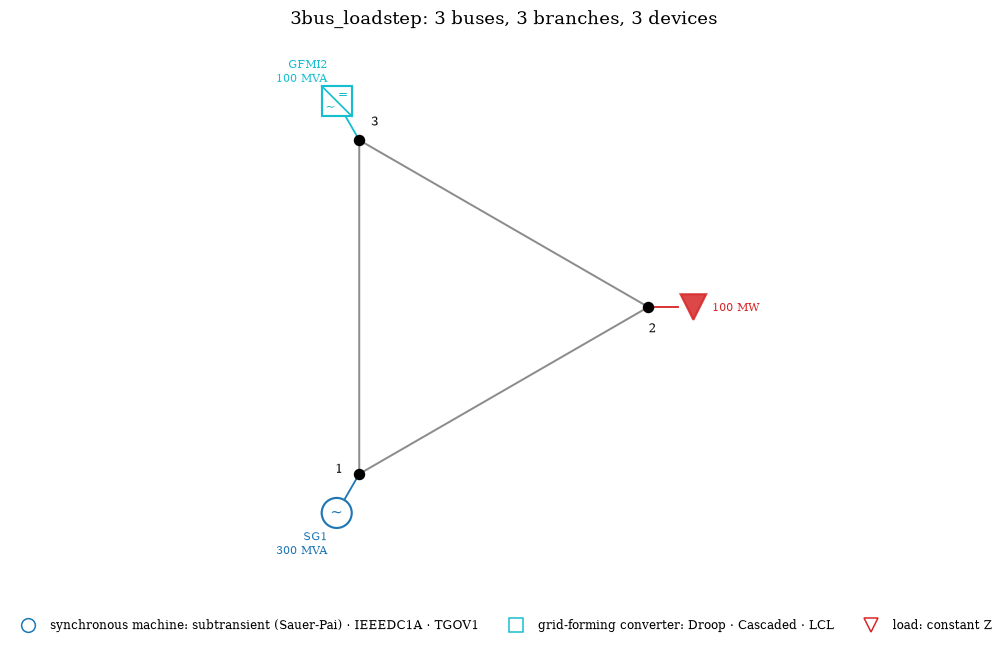

In [8]:
ha.plot_system(dae);

## 6. Every quantity has an address

Signals are addressed as `owner:quantity`. Owners are the devices (by the `idx`
you gave them), the buses (`bus1`, `bus2`, ...) and the branches (`line1-2`, ...).
Quantities are that owner's states plus derived ones: `f` in Hz, `P` in MW and
`Q` in MVAr for devices, `v` / `theta` / `P` / `Q` per bus, `i` / `P` / `Q` per
branch. `ha.signals(dae)` lists them:

In [9]:
ha.signals(dae).head(12)

,signal,owner,quantity,unit,kind,description
0,SG1:delta,SG1,delta,rad,state,mechanical rotor angle with respect to fictitious synchronous frame
1,SG1:omega,SG1,omega,p.u.,state,"absolute per unit mechanical speed (1.0 at synchronism; i.e. 1 + deviation, NOT the deviation itself)"
2,SG1:psv,SG1,psv,p.u.,state,steam valve position
3,SG1:pm,SG1,pm,p.u.,state,mechanical power
4,SG1:Efd,SG1,Efd,p.u.,state,internal field voltage
5,SG1:Rf,SG1,Rf,p.u.,state,feedback rate
6,SG1:Vr,SG1,Vr,p.u.,state,pilot exciter voltage
7,SG1:e_dprim,SG1,e_dprim,p.u.,state,d-axis voltage behind transient reactance
8,SG1:e_qprim,SG1,e_qprim,p.u.,state,q-axis voltage behind transient reactance
9,SG1:psid,SG1,psid,p.u.,state,stator flux in d axis


Every plotting and export function takes the same selector: one name
(`"SG1:omega"`), a bare quantity applied to every owner that has it (`"f"`), a
glob (`"bus*:v"`), or a list of these. Signals sharing a unit share a panel, so
a mixed selection gives one panel per unit. (`ha.get(dae, ...)` returns the same
selection as arrays, and `ha.plot_states(dae, "GFMI2")` is the small-multiples
view of every state of one device, useful when debugging a model.)

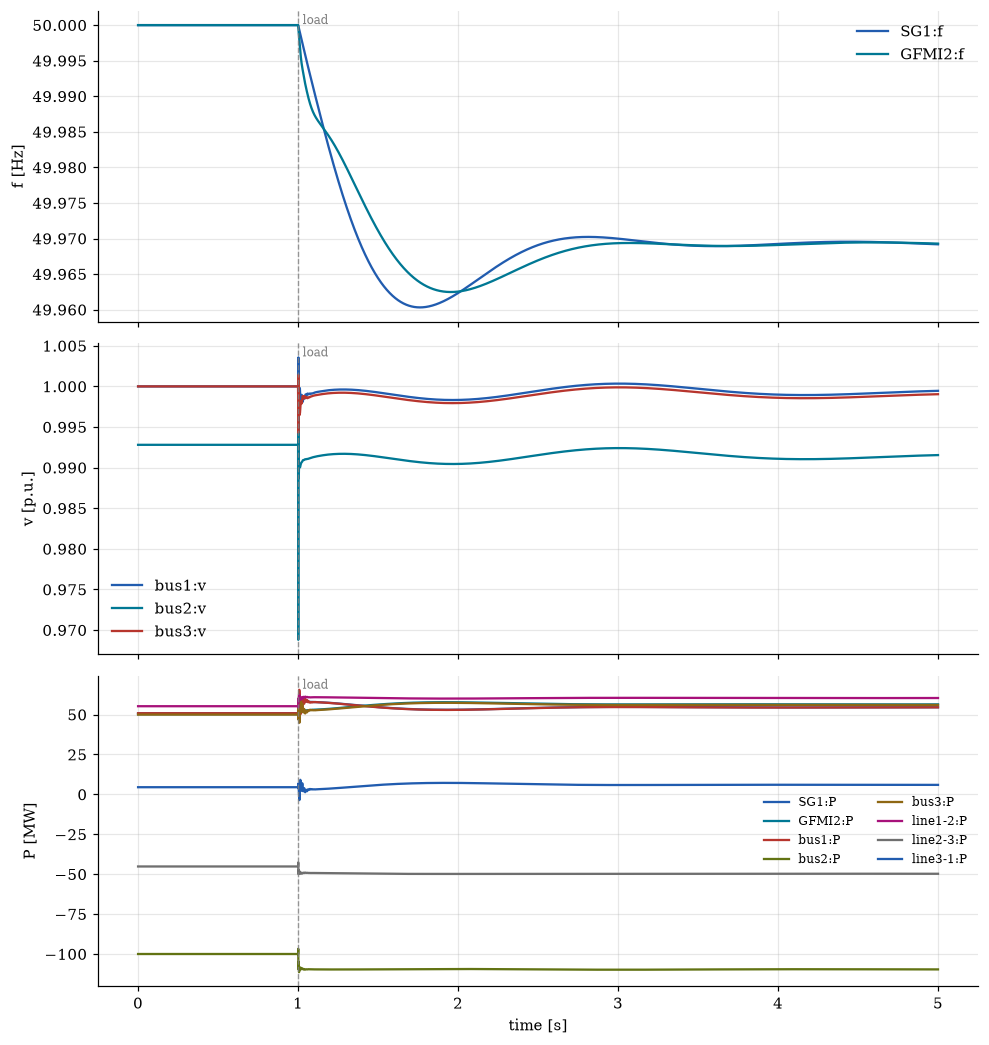

In [10]:
ha.plot(dae, ["*:f", "bus*:v", "*:P"]);

Reading the three panels:

* both units slow down after the step; the converter reacts faster (no inertia, a
  first-order power filter and a droop) and picks up most of the extra load at first,
  the machine's turbine follows through its governor,
* the frequency settles below 50 Hz: droop control shares the load but does not
  restore frequency (that is secondary control),
* the short spike in the voltages right at 1 s is the electromagnetic transient of the
  network, which is only there because the lines are modeled dynamically.

## 7. Metrics

`ha.metrics` gives the excursion summary of any set of signals (default: every
frequency): the value before the event, the worst excursion and when it happened,
the final value, and the largest rate of change. The trajectories themselves leave
as a DataFrame (`ha.to_dataframe`) or a CSV (`ha.to_csv`) with `t` plus one column
per signal, for a paper figure drawn with your own tools.

In [11]:
ha.metrics(dae).round(4)

,unit,pre-event,extreme,t_extreme [s],deviation,final,max |rate| [/s]
signal,,,,,,,
SG1:f,Hz,50.0,49.9603,1.7614,-0.0397,49.9694,0.1030
GFMI2:f,Hz,50.0,49.9625,1.9544,-0.0375,49.9694,0.3867


## 8. Change the disturbance

`sim_dist.txt` accepts six event types plus a setpoint step:

* `LOAD`: step a load by `p_delta` / `q_delta` MW/MVAr,
* `FAULT_BUS` / `CLEAR_FAULT_BUS`: a three-phase fault (admittance `y`) at a bus,
* `FAULT_LINE` / `CLEAR_FAULT_LINE`: the same on a line, quasi-static network only
  (with `line_dyn=True` the simulator skips them with a warning; use `FAULT_BUS`),
* `OPEN_LINE`: open a branch permanently,
* `SETPOINT`: step any device setpoint (`device`, `param`, `value`) at a given time.

`ha.set_disturbances` overwrites the file in your local copy (`ha.read_events`
reads it back). Below, a three-phase short circuit at the load bus (fault
admittance 20 p.u.) is applied at 1.0 s and cleared after 100 ms, and `ha.compare`
puts the fault run and the load step on the same panels. The fault run has the
deeper frequency nadir, and unlike the load step it returns to 50 Hz once the
fault is cleared, because no load changed.

In [12]:
FAULT = 'Disturbance, time = 1.0, type = "FAULT_BUS",       bus = "2", y = 20'
CLEAR = 'Disturbance, time = 1.1, type = "CLEAR_FAULT_BUS", bus = "2"'

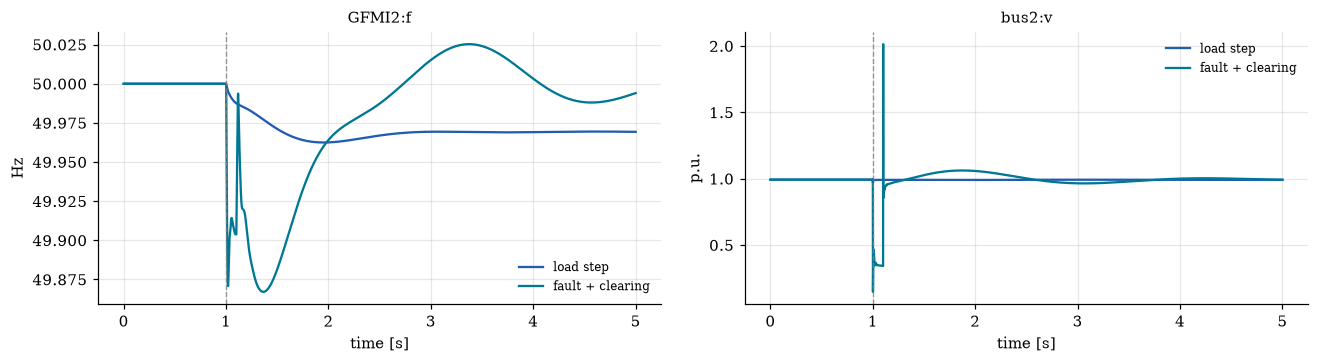

In [13]:
ha.set_disturbances(root, SYS, [FAULT, CLEAR])
dae_fault = run(SYS, system_root=root, T_end=5.0)

ha.compare({"load step": dae, "fault + clearing": dae_fault}, ["GFMI2:f", "bus2:v"]);

In [14]:
# Put the load step back for the rest of the notebook.
ha.set_disturbances(root, SYS, ['Disturbance, time = 1.0, type = "LOAD", bus = "2", p_delta = 10, q_delta = 0'])

## 9. Hybrid in one flag: quasi-static vs dynamic network

With `line_dyn=True` (what we used so far) every line carries its own current states
and the bus voltages are differential: the electromagnetic transients of the network
are kept. With `line_dyn=False` the network is the usual algebraic admittance matrix of
phasor (RMS) simulation. Same devices, same files, one flag. The time axis is
zoomed onto the switching instant, where the two models differ.

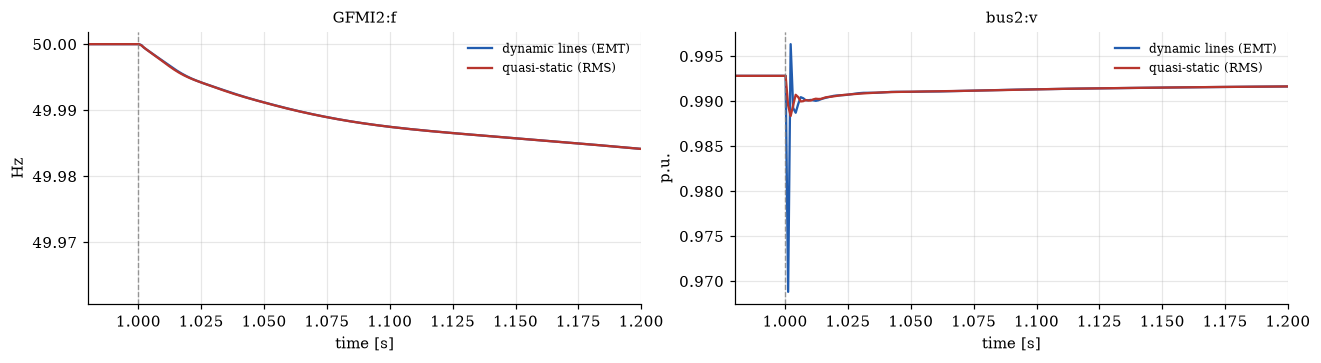

In [15]:
dae_rms = run(SYS, system_root=root, T_end=5.0, line_dyn=False)

axs = ha.compare({"dynamic lines (EMT)": dae, "quasi-static (RMS)": dae_rms},
                 ["GFMI2:f", "bus2:v"], colors=[ETH["blue"], ETH["red"]])
axs[0, 1].set_xlim(0.98, 1.2);

The electromechanical response is the same; the difference is the fast network
transient in the first tens of milliseconds. Use the dynamic network when converter
controls interact with the network at those time scales (inner current loops, PLLs,
LCL filters), the quasi-static one when you want speed on large systems.

hermess printed a warning at that run: the converter's LCL filter kept its fast
current and voltage states while the network they interact with became algebraic,
which is inconsistent. It does not affect the slow comparison above; a consistent
quasi-static setup swaps the filter strategy too, one word in the file,
`ha.set_param(root, SYS, "GFMI2", filter='"LCL_static"')`, the same mechanism
notebook 02 uses for the control strategies. And before you switch your own
system to dynamic lines: the line charging acts as the bus capacitance, so every
bus needs a connected branch with `b > 0`; if not, setup stops with the names of
the offending buses.

## 10. Small-signal analysis in one call

Because the DAE is symbolic, the Jacobian at the operating point is exact and needs
no extra modeling. `ha.modal_table` runs the eigenvalue analysis on the run you
already did and lists the modes, least damped first; `n`, `min_freq` / `max_freq`
and `oscillatory_only` select what you see.

In [16]:
ha.modal_table(dae, n=8, oscillatory_only=True, max_freq=5)

,mode,eigenvalue,f [Hz],zeta,dominant states
0,9,-0.911 ± 2.785j,0.443,0.311,"SM_SP@1:e_qprim (0.21), SM_SP@1:Efd (0.18), SM_SP@1:omega (0.15)"
1,13,-1.262 ± 2.466j,0.392,0.456,"SM_SP@1:omega (0.22), SM_SP@1:delta (0.14), GFM@3:delta_c (0.13)"
2,16,-6.860 ± 1.116j,0.178,0.987,"GFM@3:delta_c (0.34), SM_SP@1:omega (0.13), SM_SP@1:e_dprim (0.13)"
3,17,-26.876 ± 3.786j,0.603,0.990,"GFM@3:Pc_tilde (0.47), SM_SP@1:psiq2 (0.27), SM_SP@1:e_dprim (0.12)"


What the table says (the state names read `device@bus:state`):

* the slow part has one electromechanical mode, machine speed and angle swinging against
  the converter angle, at about 0.4 Hz with a damping ratio near 0.5, and an excitation
  mode (field flux and `Efd`) close to it,
* the converter's own angle and power-measurement modes are almost critically damped,
* the least damped modes overall (drop `max_freq`) are at kHz: network and LCL-filter
  resonances that exist only because the lines and the filter are modeled dynamically.

`ha.participation_table` names the states behind one mode, here the least damped
slow one (the excitation mode), and `ha.state_matrix(dae)` returns the reduced
state matrix itself when you need it.

In [17]:
MODE = int(ha.modal_table(dae, n=1, oscillatory_only=True, max_freq=2)["mode"].iloc[0])
ha.participation_table(dae, mode=MODE, top=6)

,state,participation
0,SM_SP@1:e_qprim,0.2127
1,SM_SP@1:Efd,0.1775
2,SM_SP@1:omega,0.1497
3,SM_SP@1:Vr,0.1290
4,SM_SP@1:delta,0.0879
5,GFM@3:delta_c,0.0757


`ha.plot_modes` is the s-plane view (imaginary axis in Hz, dotted rays at the
reference damping); `fmax` and `xlim` zoom onto the slow modes and `annotate=True`
writes the mode ids from the table. Called twice on one axes with `label` and
`color`, it overlays two designs or two network models (the quasi-static run
above lacks the network and filter modes the dynamic one has).

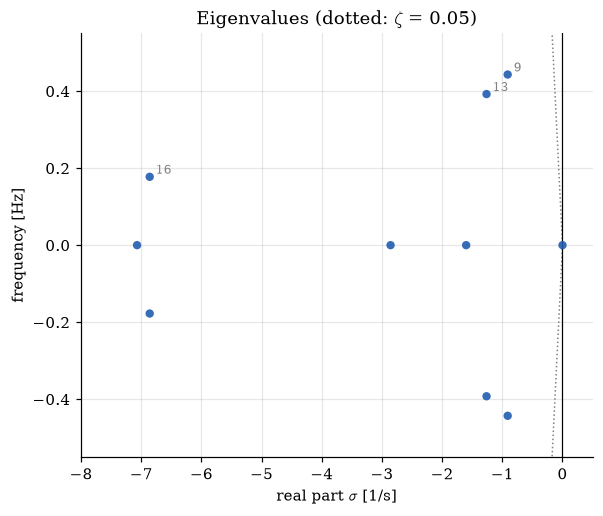

In [18]:
ha.plot_modes(dae, fmax=5, xlim=(-8, 0.5), annotate=True);

## 11. Turn a knob: droop gain and inertia

`ha.set_param` edits one device row in the local copy (numbers stay numbers,
strings keep their quotes, so `ha.set_param(root, SYS, "GFMI2", angle='"VSM"')`
would swap a control strategy). The slider reruns the simulation (well under a
second) and redraws the frequency response next to the slow eigenvalues. A larger
droop gain `Kp` means more frequency deviation per MW, and a smaller inertia `H` a
deeper, faster first swing.

In [19]:
from ipywidgets import interact, FloatSlider

def explore(Kp=0.01, H=6.5):
    ha.set_param(root, SYS, "GFMI2", Kp=Kp)
    ha.set_param(root, SYS, "SG1", H=H)
    d = run(SYS, system_root=root, T_end=5.0)
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    ha.plot_frequency(d, ax=axs[0]); axs[0].set_ylim(49.85, 50.02)
    ha.plot_modes(d, ax=axs[1], fmax=5, xlim=(-8, 0.5))
    fig.tight_layout(); plt.show()

interact(explore,
         Kp=FloatSlider(value=0.01, min=0.005, max=0.08, step=0.005, continuous_update=False, readout_format=".3f"),
         H=FloatSlider(value=6.5, min=2.0, max=12.0, step=0.5, continuous_update=False));

interactive(children=(FloatSlider(value=0.01, continuous_update=False, description='Kp', max=0.08, min=0.005, …

In [20]:
# Restore the shipped values so later cells (and notebook 02) start from the same point.
ha.set_param(root, SYS, "GFMI2", Kp=0.01)
ha.set_param(root, SYS, "SG1", H=6.5)

## Recap

* A system is two text files; a run is a `Config` and one call. The GUI is the same
  engine behind buttons (its builder writes those files), so everything it showed
  is one call here.
* Disturbances, the network model, and the reference frame are configuration, not code.
* Every quantity has an address, so plotting and exporting are one line each.
* The symbolic DAE gives the small-signal analysis of the same model without extra modeling.
* Results leave as plain data: `ha.to_csv` for figures, `hermess.extract_results`
  for a picklable container with provenance, and the `hermess` command line
  (`hermess run 3bus_loadstep --t-end 2 --set line_dyn=False`) for batch work.
* Everything used here ships with the package (`hermess.analysis`, imported as
  `ha`); the only notebook-side pieces are the ETH style and the `WS` defaults in
  the setup cell.

Notebook 02 uses the same system for what the symbolic model adds:
writing a new converter control strategy in a few lines, computing exact
sensitivities, and tuning a controller by gradient descent through the simulator.

---
## Appendix: the API on one page

Every `ha.` function documents its full signature in its docstring: type
`ha.plot?` in a cell, press Shift+Tab inside the brackets, or call `help(ha.plot)`.
The docs site (maitrayadesai.github.io/hermess, page "Analysis and plotting")
carries the same material next to the public API page and the per-model reference
with equations and symbol tables. Three places to look things up:

* what can go inside `hermess.simulate(...)` (and therefore `run(...)`): the
  `Config` fields, listed by `list(hermess.config.Config.model_fields)`; the GUI
  options dialog documents each one with a tooltip, and the CLI validates
  `--set KEY=VALUE` against the same list,
* what a device row in `sim_param.txt` accepts: the model's docstring and its
  docs page (generated from it), or the GUI builder's parameter form,
* what a strategy must implement: the abstract class, e.g.
  `help(hermess.devices.inverter_angle.AngleSource)` (notebook 02 walks it).

| Function | What it does | Section |
|---|---|---|
| `hermess.simulate(system, **config)` | run a system; any `Config` field as a keyword, `quiet=`, `progress_callback=`, `init_callback=` | 2, 4 |
| `WS` + `run(system, **overrides)` | this notebook's three-line shim over `hermess.simulate` | 0, 4 |
| `ha.list_systems(root=None)`, `hermess.SYSTEMS_DIR`, `ha.copy_system(name)`, `ha.show_system(root, name)` | the shipped systems, where they live, a local editable copy, the two files printed | 1, 3 |
| `ha.summary(dae)`, `ha.power_flow_table(dae, which)` | run summary, initial power flow per bus or branch | 4 |
| `ha.plot_system(dae, ...)` | one-line diagram; `device_labels`, `color_by` + `at`, `annotate_branches`, `pos`, `colors` | 5 |
| `ha.signals(dae, what, kind)`, `ha.signal_names`, `ha.get`, `ha.get_device` | the address book, the resolved names, the arrays, the device object | 6 |
| `ha.plot(dae, what, ...)` | any selector; `ax`, `figsize`, `title`, `events`, `label_prefix`, style kwargs | 6 |
| `ha.plot_frequency` / `ha.plot_voltages` / `ha.plot_active_power`, `ha.plot_states` | the named views; small multiples of a device's states | 6, 11 |
| `ha.metrics(dae, what, settle_from)` | excursion summary | 7 |
| `ha.to_dataframe` / `ha.to_csv(dae, path, what, every, float_format)` | trajectories as a table or a file | 7 |
| `ha.set_disturbances(root, name, rows)`, `ha.read_events` | rewrite and read `sim_dist.txt` | 8 |
| `ha.compare(runs, what, ncols, figsize, colors)` | several runs on the same panels | 8, 9 |
| `ha.set_param(root, name, idx, **values)` | edit one device row; quoted strings swap strategies | 9, 11 |
| `ha.modal_table(dae, n, min_freq, max_freq, oscillatory_only)` | the modes, least damped first | 10 |
| `ha.participation_table(dae, mode, top)`, `ha.small_signal(dae, report=True)`, `ha.state_matrix(dae)` | one mode's states, the printed report, the matrix | 10 |
| `ha.plot_modes(dae, fmax, xlim, annotate, label, color, damping_ref)` | the s-plane, overlays via `ax` | 10, 11 |
| `hermess` CLI, `hermess.extract_results(dae, cfg)` | `list`, `run`, `--set`; the picklable results container | recap |